# Job Hunting

Find hiring companies, filter by your preferences, and build shortlists.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

conn = sqlite3.connect("../data/yc_collaboration.db")
df = pd.read_sql("SELECT * FROM companies", conn)
conn.close()

df["batch_year"] = df["batch"].str.extract(r"(\d{4})").astype(float)
df["city"] = df["location"].str.split(",").str[0].str.strip()

# Base: active and hiring
hiring = df[(df["is_hiring"] == 1) & (df["status"] == "Active")].copy()
print(f"Active & hiring: {len(hiring)} companies out of {len(df)} total")

Active & hiring: 1423 companies out of 5690 total


---
## 1. Hiring Snapshot

In [2]:
print(f"{'Active & hiring':<25} {len(hiring):,}")
print(f"{'Median team size':<25} {int(hiring['team_size'].median())}")
print(f"{'Mean team size':<25} {int(hiring['team_size'].mean())}")
print(f"{'Early stage':<25} {(hiring['stage'] == 'Early').sum()}")
print(f"{'Growth stage':<25} {(hiring['stage'] == 'Growth').sum()}")
print()
print("=== By Industry ===")
print(hiring["industry"].value_counts().to_string())
print()
print("=== By Stage ===")
print(hiring["stage"].value_counts().to_string())

Active & hiring           1,423
Median team size          10
Mean team size            65
Early stage               1041
Growth stage              382

=== By Industry ===
industry
B2B                             821
Fintech                         161
Healthcare                      161
Consumer                        118
Industrials                      93
Real Estate and Construction     34
Education                        20
Government                       14
Unspecified                       1

=== By Stage ===
stage
Early     1041
Growth     382


---
## 2. Hiring by Location

Remote-friendly: 773 (54.3%)



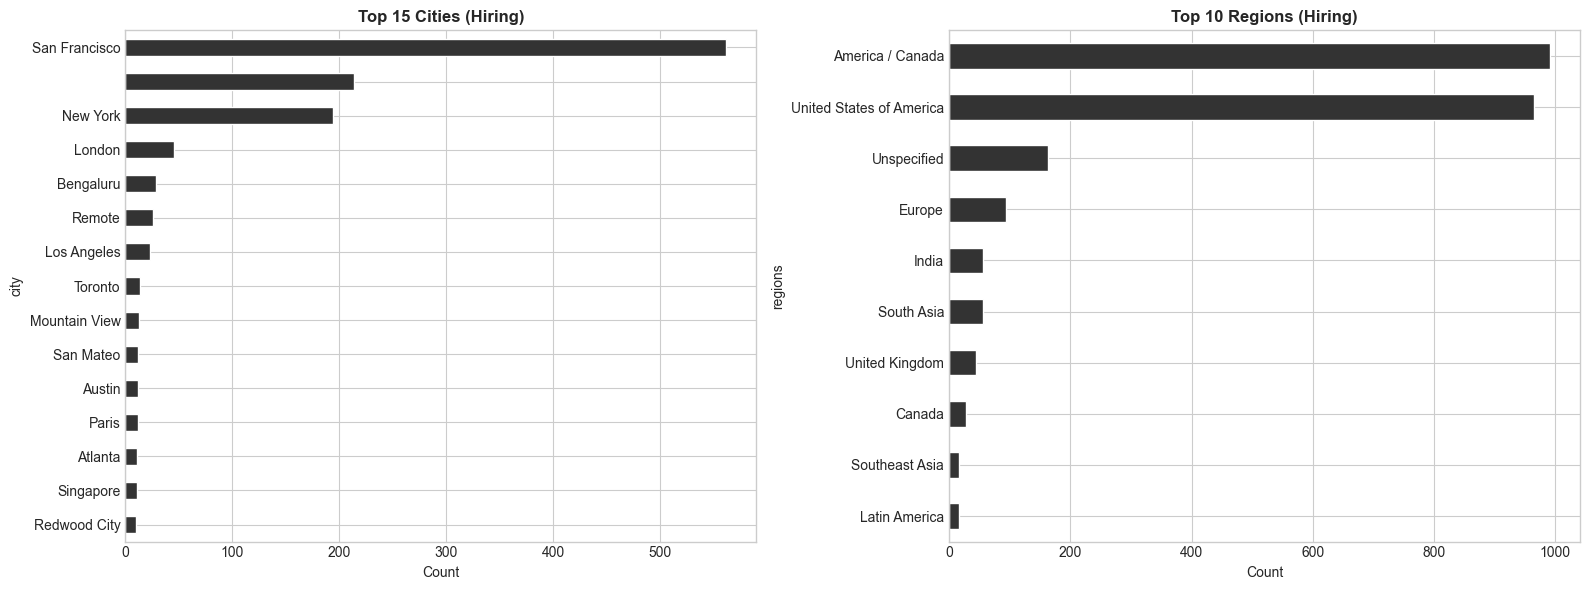

In [3]:
# Has remote in location or regions?
hiring["is_remote"] = (
    hiring["location"].str.contains("Remote", case=False, na=False) |
    hiring["regions"].str.contains("Remote", case=False, na=False)
)

remote_count = hiring["is_remote"].sum()
print(f"Remote-friendly: {remote_count} ({remote_count/len(hiring)*100:.1f}%)")
print()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

hiring["city"].value_counts().head(15).plot(kind="barh", ax=axes[0], color="#333333", edgecolor="white")
axes[0].set_title("Top 15 Cities (Hiring)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

regions = hiring["regions"].str.split("; ").explode().str.strip()
regions = regions[(regions != "") & (~regions.str.contains("Remote", na=False))]
regions.value_counts().head(10).plot(kind="barh", ax=axes[1], color="#333333", edgecolor="white")
axes[1].set_title("Top 10 Regions (Hiring)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 3. Hiring by Batch Year (Company Age)

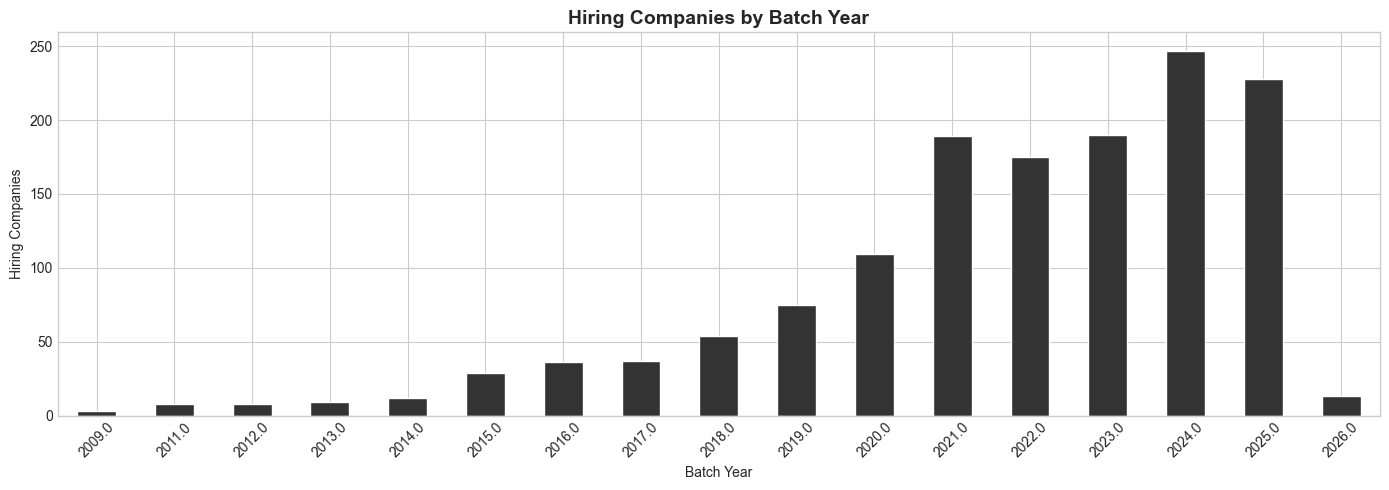


Most hiring companies come from recent batches (newer startups growing fast).


In [4]:
batch_hiring = hiring["batch_year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
batch_hiring.plot(kind="bar", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Hiring Companies by Batch Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Batch Year")
ax.set_ylabel("Hiring Companies")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nMost hiring companies come from recent batches (newer startups growing fast).")

---
## 4. Hiring by Team Size Bucket

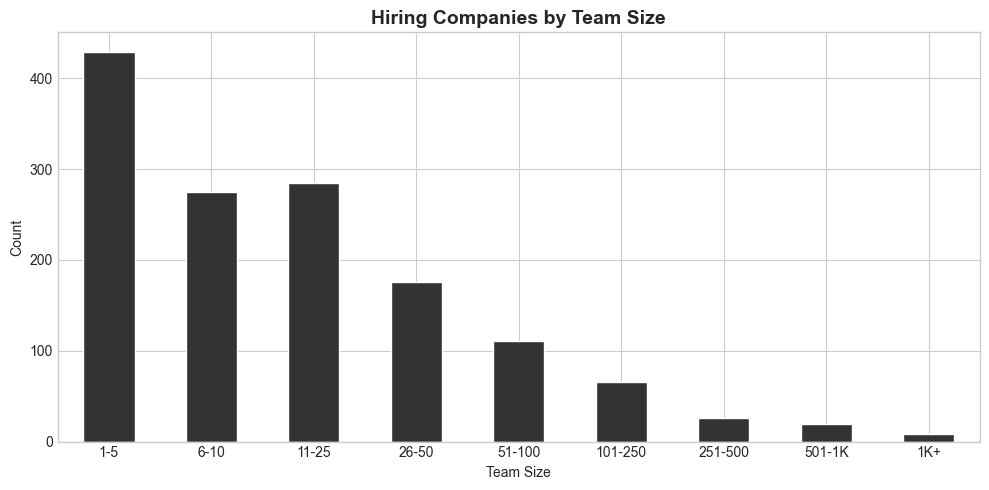


  1-5          429 companies
  6-10         275 companies
  11-25        285 companies
  26-50        176 companies
  51-100       111 companies
  101-250       66 companies
  251-500       26 companies
  501-1K        19 companies
  1K+            8 companies


In [5]:
bins = [0, 5, 10, 25, 50, 100, 250, 500, 1000, 50000]
labels = ["1-5", "6-10", "11-25", "26-50", "51-100", "101-250", "251-500", "501-1K", "1K+"]
hiring["size_bucket"] = pd.cut(hiring["team_size"], bins=bins, labels=labels)

bucket_counts = hiring["size_bucket"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bucket_counts.plot(kind="bar", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Hiring Companies by Team Size", fontsize=14, fontweight="bold")
ax.set_xlabel("Team Size")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print()
for label, count in bucket_counts.items():
    print(f"  {label:<10} {count:>5} companies")

---
## 5. Top Tags Among Hiring Companies

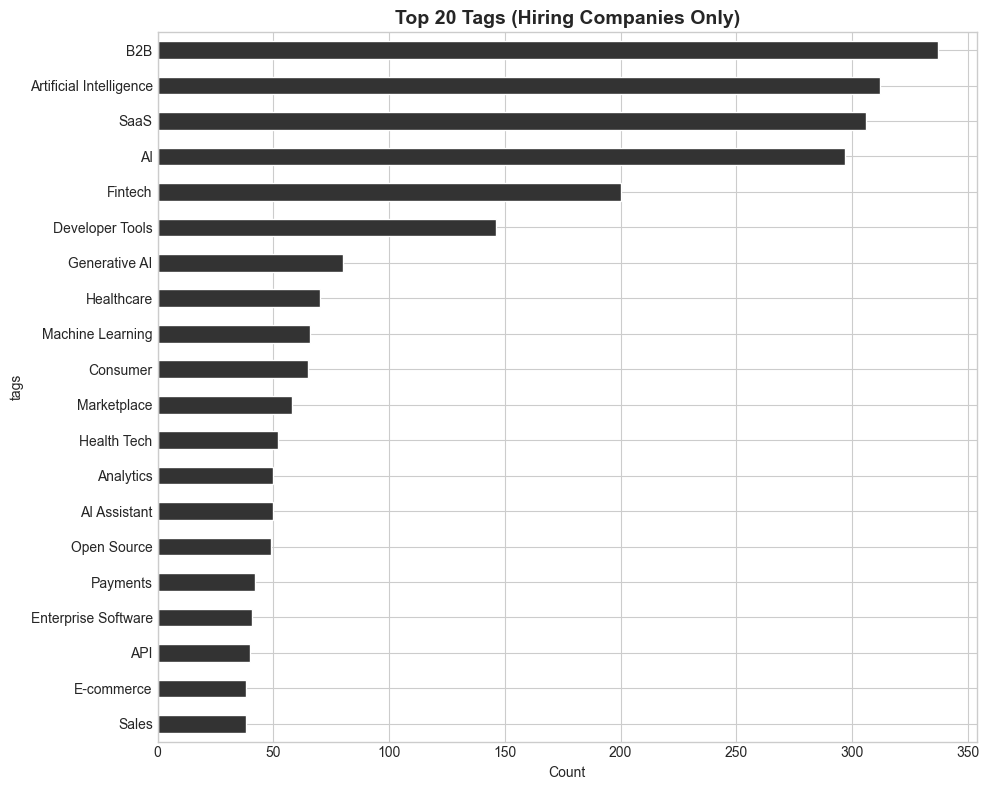

In [6]:
hiring_tags = hiring["tags"].str.split("; ").explode().str.strip()
hiring_tags = hiring_tags[(hiring_tags != "") & hiring_tags.notnull()]

fig, ax = plt.subplots(figsize=(10, 8))
hiring_tags.value_counts().head(20).plot(kind="barh", ax=ax, color="#333333", edgecolor="white")
ax.set_title("Top 20 Tags (Hiring Companies Only)", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 6. Remote-Friendly Hiring Companies

In [7]:
remote = hiring[hiring["is_remote"]].sort_values("team_size", ascending=False)

print(f"Remote-friendly & hiring: {len(remote)} companies\n")

print("=== Top 25 by Team Size ===")
remote[["name", "one_liner", "website", "team_size", "industry", "batch"]].head(25)

Remote-friendly & hiring: 773 companies

=== Top 25 by Team Size ===


,name,one_liner,website,team_size,industry,batch
229,Stripe,Economic infrastructure for the internet.,http://stripe.com,7000.0,Fintech,Summer 2009
2261,99minutos,The fastest shipping for online shopping,https://99minutos.com,5000.0,B2B,Winter 2020
1773,Deel,The all-in-one HR and payroll platform for glo...,https://www.deel.com/,5000.0,B2B,Winter 2019
1039,Rappi,On-demand delivery and financial services for ...,http://www.rappi.com,4800.0,Consumer,Winter 2016
575,Flexport,Platform for global logistics.,https://www.flexport.com/careers/jobs/,3000.0,B2B,Winter 2014
785,Razorpay,India's only full-stack financial solutions co...,https://razorpay.com,2700.0,Fintech,Winter 2015
1160,Rippling,"One place to run all your HR, IT, and Finance....",http://rippling.com/,2500.0,B2B,Winter 2017
19,Gusto,Provides growing businesses with everything to...,https://gusto.com,2400.0,B2B,Winter 2012
1108,Athelas,"Extensible, Integrated Technology that Simplif...",http://athelas.com,1000.0,Healthcare,Summer 2016
1299,Flock Safety,The first public safety operating system that ...,http://www.flocksafety.com,1000.0,B2B,Summer 2017


---
## 7. Recently Founded & Hiring (High Growth Potential)

In [8]:
recent_hiring = hiring[hiring["batch_year"] >= 2023].sort_values("team_size", ascending=False)

print(f"Founded 2023+ & hiring: {len(recent_hiring)} companies\n")

print("=== Top 30 Newest Hiring Companies ===")
recent_hiring[["name", "one_liner", "website", "team_size", "batch", "location"]].head(30)

Founded 2023+ & hiring: 678 companies

=== Top 30 Newest Hiring Companies ===


,name,one_liner,website,team_size,batch,location
4010,Alaan,Modern finance platform for the Middle East,https://www.alaan.com/,160.0,Winter 2023,"Dubai, Dubai, United Arab Emirates"
3906,Tennr,"Fast, Transparent Patient Experiences",https://www.tennr.com,135.0,Winter 2023,"New York, NY, USA"
3893,Numeral,The AI-native sales tax solution.,https://www.numeral.com/,85.0,Winter 2023,"San Francisco, CA, USA"
4280,HappyRobot,Intelligence that runs your operations.,https://happyrobot.ai,80.0,Summer 2023,"San Francisco, CA, USA"
4637,Corgi Insurance,Corgi is building an AI financial infrastructu...,https://corgi.insure,70.0,Summer 2024,"San Francisco, CA, USA"
4034,Pylon,The only customer support platform built for B2B.,https://usepylon.com/?utm_source=bookface&utm_...,70.0,Winter 2023,"San Francisco, CA, USA"
4144,Bland AI,The enterprise platform for AI phone calls,https://bland.com,65.0,Summer 2023,"San Francisco, CA, USA"
4114,HockeyStack,The operating system for inbound B2B revenue,https://hockeystack.com,65.0,Summer 2023,"San Francisco, CA, USA"
4350,Legora (formerly Leya),The AI workspace for lawyers,https://www.legora.com/,65.0,Winter 2024,"Stockholm, Stockholm County, Sweden"
4467,Astro Mechanica,Supersonics for the new Jet Age,https://astromecha.co/,52.0,Winter 2024,"San Francisco, CA, USA"


---
## 8. Established & Hiring (Stability)

In [9]:
established = hiring[(hiring["batch_year"] <= 2020) & (hiring["team_size"] >= 50)].sort_values("team_size", ascending=False)

print(f"Established (pre-2020, 50+ team) & hiring: {len(established)} companies\n")

print("=== Top 30 Established Hiring Companies ===")
established[["name", "one_liner", "website", "team_size", "batch", "location"]].head(30)

Established (pre-2020, 50+ team) & hiring: 195 companies

=== Top 30 Established Hiring Companies ===


,name,one_liner,website,team_size,batch,location
229,Stripe,Economic infrastructure for the internet.,http://stripe.com,7000.0,Summer 2009,"San Francisco, CA, USA"
2261,99minutos,The fastest shipping for online shopping,https://99minutos.com,5000.0,Winter 2020,"Mexico City, CDMX, Mexico; Santiago, Santiago ..."
1773,Deel,The all-in-one HR and payroll platform for glo...,https://www.deel.com/,5000.0,Winter 2019,"San Francisco, CA, USA; Remote"
1039,Rappi,On-demand delivery and financial services for ...,http://www.rappi.com,4800.0,Winter 2016,"Bogotá, Bogota, Colombia"
575,Flexport,Platform for global logistics.,https://www.flexport.com/careers/jobs/,3000.0,Winter 2014,"San Francisco, CA, USA"
785,Razorpay,India's only full-stack financial solutions co...,https://razorpay.com,2700.0,Winter 2015,"Bengaluru, KA, India"
1160,Rippling,"One place to run all your HR, IT, and Finance....",http://rippling.com/,2500.0,Winter 2017,"San Francisco, CA, USA"
19,Gusto,Provides growing businesses with everything to...,https://gusto.com,2400.0,Winter 2012,"San Francisco, CA, USA"
1299,Flock Safety,The first public safety operating system that ...,http://www.flocksafety.com,1000.0,Summer 2017,"Atlanta, GA, USA"
1020,Relativity Space,Building humanity’s multiplanetary future.,http://relativityspace.com,1000.0,Winter 2016,"Los Angeles, CA, USA; Seattle, WA, USA; Washin..."


---
## 8b. Non-Tech Startups (Hiring)

Companies in non-software industries — construction, food, logistics, healthcare (non-IT), etc.

In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", 80)

# Exclude heavily software/tech tags and industries
tech_tags = [
    "SaaS", "Developer Tools", "Machine Learning", "Artificial Intelligence",
    "AI", "Generative AI", "Deep Learning", "Open Source", "DevOps",
    "Infrastructure", "Data Science", "AIOps", "Cybersecurity", "Security",
    "Cloud Computing", "API", "NLP", "Computer Vision"
]
tech_pattern = "|".join(tech_tags)

non_tech = hiring[
    (hiring["industry"].isin(["Industrials", "Real Estate and Construction", "Healthcare", "Education", "Consumer", "Government"])) &
    (~hiring["tags"].str.contains(tech_pattern, case=False, na=False))
].sort_values("team_size", ascending=False)[
    ["name", "one_liner", "website", "team_size", "batch", "industry", "tags"]
].reset_index(drop=True)
non_tech.index += 1
non_tech.columns = ["Name", "One-Liner", "Website", "Team Size", "Batch", "Industry", "Tags"]
print(f"{len(non_tech)} non-tech hiring companies")
non_tech

---
## 9. Search by Skills / Keywords

Change the keyword to match your skills.

In [ ]:
def job_search(
    keyword=None,
    industry=None,
    min_team=0,
    max_team=100000,
    remote_only=False,
    min_batch_year=None,
    max_batch_year=None,
    stage=None,
):
    """Search hiring companies by your criteria."""
    result = hiring.copy()
    if keyword:
        mask = (
            result["name"].str.contains(keyword, case=False, na=False)
            | result["one_liner"].str.contains(keyword, case=False, na=False)
            | result["long_description"].str.contains(keyword, case=False, na=False)
            | result["tags"].str.contains(keyword, case=False, na=False)
        )
        result = result[mask]
    if industry:
        result = result[result["industry"].str.contains(industry, case=False, na=False)]
    if remote_only:
        result = result[result["is_remote"]]
    if min_batch_year:
        result = result[result["batch_year"] >= min_batch_year]
    if max_batch_year:
        result = result[result["batch_year"] <= max_batch_year]
    if stage:
        result = result[result["stage"] == stage]
    result = result[(result["team_size"] >= min_team) & (result["team_size"] <= max_team)]
    result = result.sort_values("team_size", ascending=False)
    print(f"Found: {len(result)} companies\n")
    return result[["name", "one_liner", "website", "team_size", "batch", "location", "industry", "tags"]]


# === EDIT THESE TO MATCH YOUR SKILLS ===

# Example: Backend / Python roles
job_search(keyword="python", remote_only=True).head(40)

Found: 7 companies



,name,one_liner,website,team_size,batch,location,industry,tags
2657,Codingal,Leading online after-school for kids & teens t...,https://www.codingal.com,60.0,Winter 2021,"Bengaluru, KA, India",Education,Education; eLearning; Edtech
2840,hotglue,Native user-facing SaaS integrations for your ...,https://hotglue.com,13.0,Summer 2021,"Washington, DC, USA",B2B,Developer Tools; SaaS; B2B
3691,CodeCrafters,Programming courses for experienced engineers,https://codecrafters.io,10.0,Summer 2022,Remote,Consumer,Developer Tools; Education; eLearning; Careers
3696,Windmill,Open-source platform to turn scripts into inte...,https://windmill.dev,10.0,Summer 2022,"Paris, Île-de-France, France",B2B,Developer Tools; SaaS; B2B; Workflow Automatio...
3987,Boundary,The programming language for AI,https://www.boundaryml.com,5.0,Winter 2023,"Seattle, WA, USA",B2B,Artificial Intelligence; Developer Tools; Gene...
3422,Livedocs,A New Kind of Notebook for Data Storytelling,https://livedocs.com,3.0,Winter 2022,"San Francisco, CA, USA; Remote",B2B,SaaS; Productivity; Analytics
4102,LiteLLM,Call every LLM API like it's OpenAI [100+ LLMs],https://www.litellm.ai/,2.0,Winter 2023,,B2B,AIOps; Artificial Intelligence; Developer Tool...


In [11]:
# Example: AI companies, 10-200 people, remote
job_search(keyword="AI", min_team=10, max_team=200, remote_only=True).head(20)

Found: 325 companies



,name,one_liner,website,team_size,batch,location,industry,tags
1374,Gem,Talent engagement platform,https://www.gem.com/,200.0,Summer 2017,"San Francisco, CA, USA",B2B,SaaS; B2B; Recruiting
2430,Spenmo,A spend management software that provides busi...,https://summitglobal.com/,200.0,Summer 2020,"Singapore, Singapore",Fintech,Fintech; SaaS
2002,Hightouch,The leading Composable CDP and AI Decisioning ...,https://hightouch.com/,200.0,Summer 2019,"San Francisco, CA, USA",B2B,Marketing; Enterprise Software; AI
1879,Vouch,Insurance and risk management tools for startu...,http://vouch.us,190.0,Summer 2019,"San Francisco, CA, USA",Fintech,Fintech; B2B
1930,Prolific,"Making diverse, high-quality data easily avail...",https://www.prolific.com,180.0,Summer 2019,"London, England, United Kingdom",B2B,AIOps; Marketplace
1808,NALA,Building Payments for the Next Billion.,http://nala.com,168.0,Winter 2019,"New York, NY, USA",Fintech,Fintech; Payments
750,Tempo,Live home fitness training powered by computer...,https://tempo.fit/,158.0,Winter 2015,"San Francisco, CA, USA",Healthcare,Machine Learning; Consumer Health Services
69,OneSignal,Engage customers through personalized omni-cha...,https://onesignal.com,150.0,Summer 2011,"San Mateo, CA, USA",B2B,Developer Tools; SaaS; B2B; Messaging; Marketing
1243,UpKeep,Mobile-first software for maintenance teams.,https://www.upkeep.com/,150.0,Winter 2017,"Los Angeles, CA, USA",B2B,SaaS; IoT; B2B
2016,InEvent,"In-Person, Hybrid and Virtual Event Management...",https://inevent.com,150.0,Summer 2019,"Atlanta, GA, USA; Remote",B2B,SaaS; GovTech; B2B


In [12]:
# Example: B2B SaaS, Growth stage
job_search(keyword="SaaS", industry="B2B", stage="Growth").head(20)

Found: 89 companies



,name,one_liner,website,team_size,batch,location,industry,tags
2261,99minutos,The fastest shipping for online shopping,https://99minutos.com,5000.0,Winter 2020,"Mexico City, CDMX, Mexico; Santiago, Santiago ...",B2B,Logistics
1773,Deel,The all-in-one HR and payroll platform for glo...,https://www.deel.com/,5000.0,Winter 2019,"San Francisco, CA, USA; Remote",B2B,Fintech; SaaS; B2B; HR Tech; Payroll
575,Flexport,Platform for global logistics.,https://www.flexport.com/careers/jobs/,3000.0,Winter 2014,"San Francisco, CA, USA",B2B,SaaS; Logistics; Supply Chain
1299,Flock Safety,The first public safety operating system that ...,http://www.flocksafety.com,1000.0,Summer 2017,"Atlanta, GA, USA",B2B,Hardware; Machine Learning; SaaS
983,Podium,Get more leads. Make more money.,https://podium.com,1000.0,Winter 2016,"Lehi, UT, USA",B2B,Fintech; SaaS; B2B; AI
614,Algolia,A developer-friendly and enterprise-grade sear...,http://www.algolia.com,810.0,Winter 2014,"San Francisco, CA, USA; Paris, Île-de-France, ...",B2B,Developer Tools; SaaS; B2B
914,Human Interest,The 401(k) for small and medium-sized businesses.,http://humaninterest.com,765.0,Summer 2015,"San Francisco, CA, USA; Remote",B2B,Fintech; SaaS; Human Resources; HR Tech; Inves...
427,Zapier,The easiest way to automate your work.,http://zapier.com,700.0,Summer 2012,"Mountain View, CA, USA; Remote",B2B,SaaS; B2B; Automation
548,Webflow,Professional website design and publishing pla...,https://webflow.com,600.0,Summer 2013,"San Francisco, CA, USA",B2B,SaaS; Design; Marketing
820,Ironclad,Digital contracting platform for legal teams.,http://ironcladapp.com,400.0,Summer 2015,"San Francisco, CA, USA",B2B,SaaS; LegalTech


In [13]:
# Example: Developer tools
job_search(keyword="Developer Tools").head(20)

Found: 147 companies



,name,one_liner,website,team_size,batch,location,industry,tags
614,Algolia,A developer-friendly and enterprise-grade sear...,http://www.algolia.com,810.0,Winter 2014,"San Francisco, CA, USA; Paris, Île-de-France, ...",B2B,Developer Tools; SaaS; B2B
66,HackerRank,Change the world to value skills over pedigree,http://hackerrank.com,300.0,Summer 2011,"Mountain View, CA, USA; Remote",B2B,Developer Tools; Recruiting
1260,Retool,Build internal tools fast.,https://retool.com,300.0,Winter 2017,"San Francisco, CA, USA",B2B,Developer Tools
65,Apollo,Apollo helps engineering teams accelerate deli...,http://apollographql.com/,200.0,Summer 2011,"San Francisco, CA, USA; Remote",B2B,Developer Tools; Open Source; GraphQL
2180,PostHog,"The single platform to analyze, test, observe,...",https://www.posthog.com,150.0,Winter 2020,"San Francisco, CA, USA; Remote",B2B,Developer Tools; B2B; Open Source
69,OneSignal,Engage customers through personalized omni-cha...,https://onesignal.com,150.0,Summer 2011,"San Mateo, CA, USA",B2B,Developer Tools; SaaS; B2B; Messaging; Marketing
1800,Alpaca,API-first stock and crypto brokerage platform,https://alpaca.markets/,150.0,Winter 2019,"San Mateo, CA, USA; Remote",Fintech,Developer Tools; Fintech; API; Investing; Infr...
907,Bitmovin,Powers OTT online video providers with video d...,http://bitmovin.com,145.0,Summer 2015,"San Francisco, CA, USA",B2B,Developer Tools; Video
2019,Freshpaint,"Customer data collection, safeguarding, & acti...",https://freshpaint.io,120.0,Summer 2019,"San Francisco, CA, USA; Remote",B2B,Developer Tools; SaaS; B2B
2655,Quicknode,Tools & infra to build and scale high-quality ...,https://www.quicknode.com,115.0,Winter 2021,"Miami, FL, USA",B2B,Developer Tools; SaaS; Crypto / Web3; API


---
## 10. Export Shortlist

Save your filtered results to a CSV for tracking applications.

In [14]:
# Run your search and save
my_shortlist = job_search(keyword="AI", min_team=5, remote_only=True)

# Save to CSV
output_path = "../data/my_job_shortlist.csv"
my_shortlist.to_csv(output_path, index=False)
print(f"Saved {len(my_shortlist)} companies to {output_path}")

Found: 461 companies

Saved 461 companies to ../data/my_job_shortlist.csv
